In [1]:
# Hemora_Thalassemia_YOLO11_Advanced.ipynb #

# 1. SETUP & INSTALLATION
# Ultralytics supports YOLOv8, YOLOv9, YOLOv10, and YOLO11
!pip install -q ultralytics
import os
import zipfile
import shutil
import matplotlib.pyplot as plt
from google.colab import drive
from ultralytics import YOLO

# ==========================================
# 1. DRIVE MOUNT & PATHS
# ==========================================
print("Step 1: Mounting Google Drive...")
drive.mount('/content/drive')

# Ensure this path matches your updated dataset location
ZIP_PATH = '/content/drive/MyDrive/Hemora Research Thalassemia Component/Data Set/thalassemia_dataset_new.zip'
RESULTS_DIR = '/content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/YOLO11_Model'

if not os.path.exists(RESULTS_DIR):
    os.makedirs(RESULTS_DIR)

# ==========================================
# 2. DATA EXTRACTION
# ==========================================
print("\nStep 2: Extracting Dataset...")
LOCAL_ROOT = '/content/dataset'
if os.path.exists(LOCAL_ROOT): shutil.rmtree(LOCAL_ROOT)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(LOCAL_ROOT)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Step 1: Mounting Google Drive...
Mounted at /content/drive

Step 2: Extracting Dataset...


In [2]:
# ==========================================
# 3. TRAINING YOLO11-CLS
# ==========================================
print("\n🚀 Starting YOLO11 Training...")

# Load the NEW YOLO11 classification model (Nano version)
# You can also use 'yolo11s-cls.pt' (Small) or 'yolo11m-cls.pt' (Medium)
model = YOLO('yolo11n-cls.pt')

# Train the model
# imgsz=224 is standard for cell classification
results = model.train(
    data=os.path.join(LOCAL_ROOT, 'thalassemia_dataset'), # Path to dataset root
    epochs=15,
    imgsz=224,
    batch=32,
    project=RESULTS_DIR,
    name='thalassemia_yolo11_run'
)



🚀 Starting YOLO11 Training...
Ultralytics 8.3.247 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/thalassemia_dataset, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=thalassemia_yolo11_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_


Upload a Full Smear Image for YOLO11 analysis:


Saving B9780702031472000018_f001-001b-9780702031472.jpg to B9780702031472000018_f001-001b-9780702031472.jpg
Analyzing smear with YOLO11: B9780702031472000018_f001-001b-9780702031472.jpg...

image 1/1 /content/B9780702031472000018_f001-001b-9780702031472.jpg: 224x224 Normal 0.82, Thalassemia 0.18, 24.0ms
Speed: 3.6ms preprocess, 24.0ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)


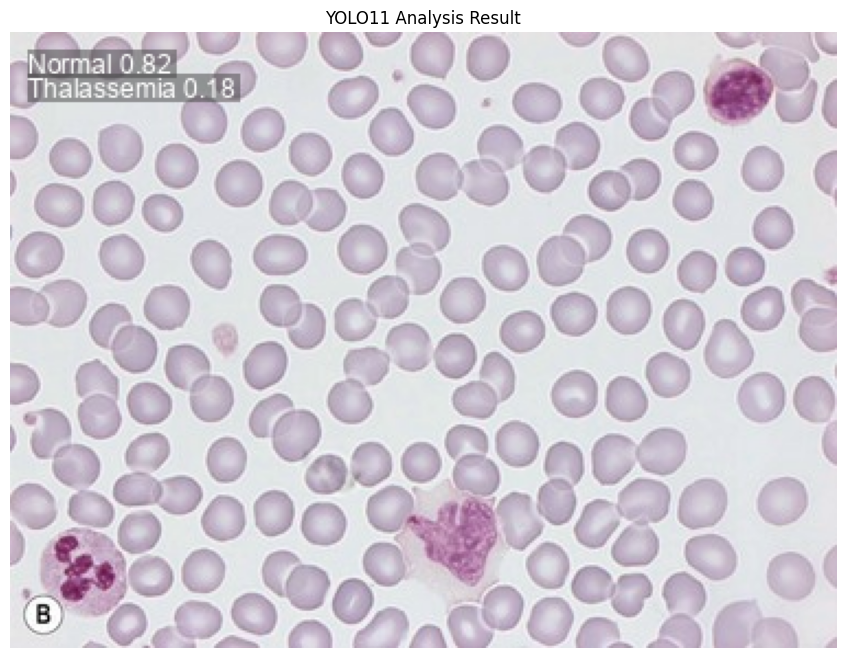

BETA-THALASSEMIA (MINOR) YOLO11 SCREENING
Primary Morphology Detected: NORMAL
Confidence Level:            82.16%

>>> RESULT: NEGATIVE - Smear appears normal.


In [5]:

# ==========================================
# 4. FINAL STEP: YOLO11 FULL SMEAR PIPELINE
# ==========================================
from google.colab import files
from PIL import Image

def analyze_with_yolo11(image_path):
    print(f"Analyzing smear with YOLO11: {image_path}...")

    # Run inference
    # YOLO11's improved architecture is better at capturing fine-grained details
    results = model(image_path)

    # Process results
    res = results[0]
    probs = res.probs  # Classification probabilities

    # Visualization using YOLO's built-in plotting
    res_plotted = res.plot()
    plt.figure(figsize=(12, 8))
    plt.imshow(res_plotted)
    plt.axis('off')
    plt.title("YOLO11 Analysis Result")
    plt.show()

    # Clinical Report
    print("="*50)
    print("BETA-THALASSEMIA (MINOR) YOLO11 SCREENING")
    print("="*50)
    top1_idx = probs.top1
    label = res.names[top1_idx]
    conf = probs.top1conf.item()

    print(f"Primary Morphology Detected: {label.upper()}")
    print(f"Confidence Level:            {conf*100:.2f}%")

    if label.lower() == 'thalassemia' and conf > 0.5:
        print("\n>>> RESULT: POSITIVE - Thalassemia Minor indicators found.") #
    else:
        print("\n>>> RESULT: NEGATIVE - Smear appears normal.")
    print("="*50)

# --- EXECUTE DEMO ---
print("\nUpload a Full Smear Image for YOLO11 analysis:")
uploaded = files.upload()
if uploaded:
    fname = list(uploaded.keys())[0]
    analyze_with_yolo11(fname)